In [2]:
require(data.table)
require(tidyverse)
require(phyloseq)
require(ggplot2)
require(RColorBrewer)
require(metacoder)
require(vegan)
require(DESeq2)

In [3]:

#look at how many reads per sample, are there any samples needed to exclude
# dig into Date_16S
## post dada2 (before making ps object)- distribution of read lengths are the same (specif for Date_16S)
### track df
# rerun post phyloseq 

## post dada2 16S figures to find what data we are working with
### reads distributed (across samples, spec, Health_status, seq_run, Month_year)

# using vegan to map out stats and ordination plots for 16S sequences

In [6]:
ps<-readRDS(file = "/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/BEL_16S_ITS2/BEL_16S_outputs/ps_16S.rds")
#removing any taxa that don't show up in any samples to speed up the process
ps <- prune_taxa(taxa_sums(ps) > 0, ps)
ps

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 266732 taxa and 470 samples ]
sample_data() Sample Data:       [ 470 samples by 9 sample variables ]
tax_table()   Taxonomy Table:    [ 266732 taxa by 6 taxonomic ranks ]

In [7]:
# remove low read counts
ps_high <- prune_samples(sample_sums(ps) >= 10000, ps)

In [8]:
#isolate just bacteria
ps_bac=subset_taxa(ps_high, Kingdom=="Bacteria")
ps_bac
#remove chloroplast order
ps_nochlo=subset_taxa(ps_bac, Order!="Chloroplast")
ps_nochlo
#remove mitochondria family
ps_nomit=subset_taxa(ps_nochlo, Family!="Mitochondria")
ps_nomit

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 103207 taxa and 467 samples ]
sample_data() Sample Data:       [ 467 samples by 9 sample variables ]
tax_table()   Taxonomy Table:    [ 103207 taxa by 6 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 78175 taxa and 467 samples ]
sample_data() Sample Data:       [ 467 samples by 9 sample variables ]
tax_table()   Taxonomy Table:    [ 78175 taxa by 6 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 46474 taxa and 467 samples ]
sample_data() Sample Data:       [ 467 samples by 9 sample variables ]
tax_table()   Taxonomy Table:    [ 46474 taxa by 6 taxonomic ranks ]

In [9]:
#dont normalize before removing mit and chlo

In [10]:
#normalizing ps by converting rawcounts into relative abundances
#so samples with more reads wont be over represented
#using ps bc only to the count data (OTU table), while preserving the rest of the object
ps_norm = transform_sample_counts(ps_nomit, function(x) 1E6 * x / sum(x))
ps_norm

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 46474 taxa and 467 samples ]
sample_data() Sample Data:       [ 467 samples by 9 sample variables ]
tax_table()   Taxonomy Table:    [ 46474 taxa by 6 taxonomic ranks ]

In [11]:
# convert the sample_data() within a phyloseq object to a vegan compatible data object
pssd2veg <- function(ps_norm) {
  sd_nomit <- sample_data(ps_norm)
  return(as(sd_nomit,"data.frame"))
}
#using phyloseq nmds plot no chloroplast
sample_nomit <- pssd2veg(ps_norm)

In [12]:
class(sample_nomit)

[1] "data.frame"

In [13]:
# convert the otu_table() within a phyloseq object to a vegan compatible data object
psotu2veg <- function(ps_norm) {
  otu_nomit <- otu_table(ps_norm)
  if (taxa_are_rows(otu_nomit)) {
    otu_nomit <- t(otu_nomit)
  }
  return(as(otu_nomit, "matrix"))
}

# Extract normalized OTU matrix and sample data
otu_nomit <- psotu2veg(ps_norm)

In [14]:
class(otu_nomit)

[1] "matrix" "array"

### clean sample metadata

In [15]:
#save sammple names as a column so tidy doesn't get rid of it during filtering
sample_nomit$SampleID <- rownames(sample_nomit)

In [16]:
head(sample_nomit)

,Health_status,colony,Date_16S,Condition,Species,Month_year,Seq_run,Transect,DateFormatted,SampleID
,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<chr>,<date>,<chr>
052022_BEL_CBC_T1_2_SSID,Diseased_Tissue,1_3,1_22_2025,Diseased,SSID,May 2022,1,CBC30N,2022-05-21,052022_BEL_CBC_T1_2_SSID
092023_BEL_CBC_T1_175_PAST,Healthy,1_13,1_22_2025,Healthy,PAST,Sep 2023,1,CBC30N,2023-09-25,092023_BEL_CBC_T1_175_PAST
022024_BEL_CBC_T3_851_PSTR,Healthy,3_70,1_23_2025,Healthy,PSTR,Feb 2024,1,Lagoon,2024-02-24,022024_BEL_CBC_T3_851_PSTR
082024_BEL_CBC_T4_1609_OFAV,Healthy,4_78,1_23_2025,Healthy,OFAV,Aug 2024,1,Curlew,2024-08-22,082024_BEL_CBC_T4_1609_OFAV
122023_BEL_CBC_T3_526_SSID,Healthy,3_5,1_23_2025,Healthy,SSID,Dec 2023,1,Lagoon,2023-12-16,122023_BEL_CBC_T3_526_SSID
112023_BEL_CBC_T4_399_MCAV,Bleached_Tissue,4_76,1_23_2025,CLP,MCAV,Nov 2023,1,Curlew,2023-11-13,112023_BEL_CBC_T4_399_MCAV


In [17]:
# 2. reorder MonthYear as a factor in chronological order
sample_nomit$Month_year <- factor(sample_nomit$Month_year,
        levels = unique(sample_nomit$Month_year[order(sample_nomit$DateFormatted)])
)

In [18]:
## check to make sure meta and otu table are still compatible

# Should return TRUE
all(rownames(sample_nomit) == rownames(otu_nomit))

[1] TRUE

# vegan cluster analysis

In [19]:
class(otu_nomit)
class(sample_nomit)
otu_df <- as.data.frame(otu_nomit)

[1] "matrix" "array"

[1] "data.frame"

In [20]:
head(otu_df)

,GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCATGCAGGTGGTTTGTTAAGTCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATAGCATTTGAAACTGGCAGACTAGAGTACTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAGATACTGACACTCAGATGCGAAAGCGTGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGAGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,GCAAGCGTTGTTCGGAATTACTGGGCGTAAAGGGCGTGTAGGCGGATTATCAAGTTAGGGGTGAAATCCCGGGGCTCAACCTCGGCACTGCCTTTAAGACTGATAATCTAGAGTATGTGAGGGGATAATGGAATACCTAGTGTAGAGGTGAAATTCGTAGATATTAGGTGGAACACCAGTGGCGAAGGCGATTATCTGGCACATTACTGACGCTGAGGCGCGAAAGCGTGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGGGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,TCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCGCGTAGGCGGTTTGCTAAGTCAGATGTGAAATCCCTGGGCTTAACCTAGGAACTGCATTTGAAACTAGCAAGCTAGAGTATGGTAGAGGTGGGTGGAATTTCAGGTGTAGCGGTGGAATGCGTAGAGATCTGAAGGAACATCAGTGGCGAAGGCGGCTCACTGGGCCATCACTGACGCTGAGGTGCGAAAGCGTGGGT,GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCATGCAGGTGGTTTGTTAAGTCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATTGCATTTGAAACTGGCAGACTAGAGTACTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAGATACTGACACTCAGATGCGAAAGCGTGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGCGCGTAGGCGGTGTGTTAAGTCGGATGTGAAAGCCCAGGGCTCAACCTTGGAATTGCATCCGATACTGGCACGCTAGAGTGCAGTAGAGGGAGGTGGAATTTCCGGTGTAGCGGTGAAATGCGTAGAGATCGGAAGGAACACCAGTGGCGAAGGCGGCCTCCTGGACTGACACTGACGCTGAGGTGCGAAAGCGTGGGG,GCAAGCGTTGTTCGGATTTACTGGGCGTAAAGGGTGCGTAGGTGGCATGACAAGTCACTTGTGAAATCTCCGAGCTTAACTCGGAACGGTCAAGTGATACTGTTGTGCTAGAGTGCGGGAAGGGCAGCTGGAATTCTTGGTGTAGCGGTGAAATGCGTAGATATCAAGAGGAACACCGGAGGCGAAGGCGAGTTGCTAGACCGACACTGACGCTGAGGCACGAAAGCCAGGGG,GCAAGCGTTATCCGGATTTACTGGGTTTAAAGAGTGCGTAGGCGGCTTCTTAAGTCAGTGGTGAAAGCTTAGCGCTTAACGCTAGAAGTGCCACTGATACTGGGAAGCTTGAGTCAAGAAGAGGTAAGCAGAATTCATAGTGTAGCAGTGAAATGCTTAGATACTATGAGGAATACCAACAGCGAAGGCAGCTTACTGGTCTTGTACTGACGTTGAGGCACGAAAGCGTGGGT,GCGAGCGTTGTTCGGAATTATTGGGCGTAAAGGGCGCGTAGGCGGACGTGCAAGTCTGGTGTGAAAGACCGCAGCTCAACTGCGGGCACGCGCTGGAAACTGTATGTCTTGAATCCTTGAGGGGGAACTGGAATTCCTGGTGTAGGGGTGAAATCTGTAGATATCAGGAAGAACACCGGTGGCGAAGGCGAGTTCCTGGCAAGTGATTGACGCTGAGGCGCGAAAGCGTGGGG,⋯,CCAAACGTTATCCGGATTTACTGGGCGTAAAGCGCGTGCAGGCGGTTTGGTAAGTTGGGTGTCAAAGCTCCGGGCTCAACCCGGAGAGGTCGCCCAAAACTGCCAGGCTAGAGGACGATAGAGGAAGGTGGAATTCCGGGTGTAGTGGTGAAATGCGTAGATATCCGGAGGAACACCAGTGGCGAAGGCGGCCTTCTGGGTCGTTCCTGACGCTCAGACGCGAAAGCTAGGGT,GCAAGCGTTATCCGGAATGACTGGGTGTAAAGAGCATGTAGGCGGGGATGCAAGTCAGATGTGAAATCTTAAGGCTCAACCTTATTGAGCATCTGAAACTGTGTTTCTTGAGTACTGGAGAGGAAAGTGGAATTCCTAGTGTAGCGGTGAAATGCGTAGATATTAGGAGGAACACCAGTGGCGAAGGCGGCTTTCTGGACAGTAACTGACGCTGAGATGCGAAAGTGTGGGT,GCAAGCGTTATTCGGAATTACTGGGCGTAAAGGGCGCGCAGGCGGCCCGTTAAGTGAGAAGTGAAAGCCCCGGGCTCAACCCGGGAATTGCTTCTCATACTGGCAGGCTAGAGGATGGGAGAGGAAAATGGAATTCCCGGTGTAGCGGTGAAATGCGTAGAGATCGGGAGGAACACCAGTGGCGAAGGCGGTTTTCTGGACCATTACTGACGCTGAGGCGCGAAAGCGTGGGG,GCAAGCGTTGTTCGGATTCATTGGGTGTAAAGGGTATGTAGGTGTCCTGCCAAGTCTTTCTTGAAATACTCTGGCTCAACCAGAGACCCGGGAGAGAAACTGGCAGGATTGAGTACTGGAGAGGAAAGCGGAATTCCCGGTGTAAGGGTGAAATCTGTAGATATCGGGAGGAACACCAGTGGCGAAAGCGGCTTTCTGGCCAGATACTGACACTGAAATACGAAAGCAAGGGG,ACGAACGTTATTCGGAATTACTGGGCTTAAAGGGTGCGCAGGCGGTCTGGCGGGTTGGGTGTGAAAGCCCTCGGCTCAACCGGGGAACTGCGCTCAATACCACCAGGCTCGAGCGAGATAGAGGTGAGCGGAACTACGGGTGGAGCGGTGGAATGCGTTGATATCCGTGGGAACACCGGCGGCGAAAGCGGCTCACTGGGTCTCTGCTGACGCTCAGGCACGAAAGCTAGGGG,GGTGCGGTAAGTGAGGTGTGAAATCCCCCGGCTCAACCGAGGAATTGCGCTTCATACTGCCGTGCTAGAGGGAGACAGAGGTAAGCGGAACTGATGGTGGAGCGGTGAAATGCGTTGATATCATCAGGAACACCGGTGGCGAAAGCGGCTTACTGGGTCTCTTCTGACGCTGAGGCACGAAAGCTAGGGTAGCGAACGGGATTAGATACCCGGGTAGTCC,GCAAGCGTTATTCGGAATTATTGGGCGTAAAGGGTCTGTAGGTGGTTTGTTAAGTCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATAGCATTTGAAACTGGCAGACTAGAGTACTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAGATCCTGACACTCAGATGCGACAGCGTGGGG,GGTGAGTCAAGTTACCTATGAAAGATACAGGCT

In [21]:
# check to make sure otu and sample are compatible
class(sample_nomit)
class(otu_df)

# merge otu and sam_clean by sample ID
otu_df$SampleID <- rownames(otu_df)

[1] "data.frame"

[1] "data.frame"

In [22]:
otu_merged <- merge(otu_df, sample_nomit, by = "SampleID",
                    all = TRUE, sort = FALSE)

In [23]:
head(otu_merged)

,SampleID,GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCATGCAGGTGGTTTGTTAAGTCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATAGCATTTGAAACTGGCAGACTAGAGTACTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAGATACTGACACTCAGATGCGAAAGCGTGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGAGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,GCAAGCGTTGTTCGGAATTACTGGGCGTAAAGGGCGTGTAGGCGGATTATCAAGTTAGGGGTGAAATCCCGGGGCTCAACCTCGGCACTGCCTTTAAGACTGATAATCTAGAGTATGTGAGGGGATAATGGAATACCTAGTGTAGAGGTGAAATTCGTAGATATTAGGTGGAACACCAGTGGCGAAGGCGATTATCTGGCACATTACTGACGCTGAGGCGCGAAAGCGTGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGGGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,TCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCGCGTAGGCGGTTTGCTAAGTCAGATGTGAAATCCCTGGGCTTAACCTAGGAACTGCATTTGAAACTAGCAAGCTAGAGTATGGTAGAGGTGGGTGGAATTTCAGGTGTAGCGGTGGAATGCGTAGAGATCTGAAGGAACATCAGTGGCGAAGGCGGCTCACTGGGCCATCACTGACGCTGAGGTGCGAAAGCGTGGGT,GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCATGCAGGTGGTTTGTTAAGTCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATTGCATTTGAAACTGGCAGACTAGAGTACTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAGATACTGACACTCAGATGCGAAAGCGTGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGCGCGTAGGCGGTGTGTTAAGTCGGATGTGAAAGCCCAGGGCTCAACCTTGGAATTGCATCCGATACTGGCACGCTAGAGTGCAGTAGAGGGAGGTGGAATTTCCGGTGTAGCGGTGAAATGCGTAGAGATCGGAAGGAACACCAGTGGCGAAGGCGGCCTCCTGGACTGACACTGACGCTGAGGTGCGAAAGCGTGGGG,GCAAGCGTTGTTCGGATTTACTGGGCGTAAAGGGTGCGTAGGTGGCATGACAAGTCACTTGTGAAATCTCCGAGCTTAACTCGGAACGGTCAAGTGATACTGTTGTGCTAGAGTGCGGGAAGGGCAGCTGGAATTCTTGGTGTAGCGGTGAAATGCGTAGATATCAAGAGGAACACCGGAGGCGAAGGCGAGTTGCTAGACCGACACTGACGCTGAGGCACGAAAGCCAGGGG,GCAAGCGTTATCCGGATTTACTGGGTTTAAAGAGTGCGTAGGCGGCTTCTTAAGTCAGTGGTGAAAGCTTAGCGCTTAACGCTAGAAGTGCCACTGATACTGGGAAGCTTGAGTCAAGAAGAGGTAAGCAGAATTCATAGTGTAGCAGTGAAATGCTTAGATACTATGAGGAATACCAACAGCGAAGGCAGCTTACTGGTCTTGTACTGACGTTGAGGCACGAAAGCGTGGGT,⋯,GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCACGCAGGCGGTTTGTTAAGCTAGATGTGAAAGCCCCGGGCTCAACCTGGGATGGTCATTTAGAACTGGCAGACTAGAGTCTTGGAGAGGGGAGTGGAATTCCAGGTGTAGCGGTGAAATGCGTAGATATCTGGAGGAACATCAGTGGCGAAGGCGACTCCCTGGAAAAAGACTGACGCTCATGTGCGAAAGTGTGGGT,Health_status,colony,Date_16S,Condition,Species,Month_year,Seq_run,Transect,DateFormatted
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<chr>,<date>
1,052022_BEL_CBC_T1_2_SSID,10555.5628,62814.0377,207.7356,2285.0911,0.0000,5712.7277,0.0000,90.8843,0.0000,⋯,0,Diseased_Tissue,1_3,1_22_2025,Diseased,SSID,May 2022,1,CBC30N,2022-05-21
2,092023_BEL_CBC_T1_175_PAST,216.1737,160879.1065,622.3183,61308.1786,537.1590,0.0000,0.0000,137.5651,163.7680,⋯,0,Healthy,1_13,1_22_2025,Healthy,PAST,Sep 2023,1,CBC30N,2023-09-25
3,022024_BEL_CBC_T3_851_PSTR,835.5046,3682.2498,1920.7993,1356.6184,439.2859,0.0000,0.0000,86.1345,1296.3242,⋯,0,Healthy,3_70,1_23_2025,Healthy,PSTR,Feb 2024,1,Lagoon,2024-02-24
4,082024_BEL_CBC_T4_1609_OFAV,366.1117,481.7259,572241.5412,152.8677,47800.0542,142.5909,0.0000,150.2985,990.4284,⋯,0,Healthy,4_78,1_23_2025,Healthy,OFAV,Aug 2024,1,Curlew,2024-08-22
5,122023_BEL_CBC_T3_526_SSID,695.1473,2453.4609,1359.6263,940.4934,337.3509,531.5832,0.0000,0.0000,0.0000,⋯,0,Healthy,3_5,1_23_2025,Healthy,SSID,Dec 2023,1,Lagoon,2023-12-16
6,112023_BEL_CBC_T4_399_MCAV,8130.7026,12272.4702,7167.8562,6373.1259,2506.4572,2047.9589,183.3993,150968.1955,520471.9475,⋯,0,Bleached_Tissue,4_76,1_23_2025,CLP,MCAV,Nov 2023,1,Curlew,2023-11-13


In [24]:
rownames(otu_merged) <- otu_merged$SampleID

In [25]:
otu_merged$SampleID <- NULL

In [26]:
class(otu_merged)
head(otu_merged)
nrow(otu_df)
nrow(otu_merged)
all(rownames(otu_df) == rownames(otu_merged))

[1] "data.frame"

,GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCATGCAGGTGGTTTGTTAAGTCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATAGCATTTGAAACTGGCAGACTAGAGTACTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAGATACTGACACTCAGATGCGAAAGCGTGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGAGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,GCAAGCGTTGTTCGGAATTACTGGGCGTAAAGGGCGTGTAGGCGGATTATCAAGTTAGGGGTGAAATCCCGGGGCTCAACCTCGGCACTGCCTTTAAGACTGATAATCTAGAGTATGTGAGGGGATAATGGAATACCTAGTGTAGAGGTGAAATTCGTAGATATTAGGTGGAACACCAGTGGCGAAGGCGATTATCTGGCACATTACTGACGCTGAGGCGCGAAAGCGTGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGTGCGTAGGCGGCCTTTTAAGTTGGATGTGAAAGCCCCGGGCTTAACCTGGGAACGGCATCCAAAACTGGGAGGCTCGAGTGCGGAAGAGGAGTGTGGAATTTCCTGTGTAGCGGTGAAATGCGTAGATATAGGAAAGAACACCAGTGGCGAAGGCGACACTCTGGTCTGACACTGACGCTGAGGTACGAAAGCGTGGGG,TCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCGCGTAGGCGGTTTGCTAAGTCAGATGTGAAATCCCTGGGCTTAACCTAGGAACTGCATTTGAAACTAGCAAGCTAGAGTATGGTAGAGGTGGGTGGAATTTCAGGTGTAGCGGTGGAATGCGTAGAGATCTGAAGGAACATCAGTGGCGAAGGCGGCTCACTGGGCCATCACTGACGCTGAGGTGCGAAAGCGTGGGT,GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCATGCAGGTGGTTTGTTAAGTCAGATGTGAAAGCCCGGGGCTCAACCTCGGAATTGCATTTGAAACTGGCAGACTAGAGTACTGTAGAGGGGGGTAGAATTTCAGGTGTAGCGGTGAAATGCGTAGAGATCTGAAGGAATACCGGTGGCGAAGGCGGCCCCCTGGACAGATACTGACACTCAGATGCGAAAGCGTGGGG,GCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGCGCGTAGGCGGTGTGTTAAGTCGGATGTGAAAGCCCAGGGCTCAACCTTGGAATTGCATCCGATACTGGCACGCTAGAGTGCAGTAGAGGGAGGTGGAATTTCCGGTGTAGCGGTGAAATGCGTAGAGATCGGAAGGAACACCAGTGGCGAAGGCGGCCTCCTGGACTGACACTGACGCTGAGGTGCGAAAGCGTGGGG,GCAAGCGTTGTTCGGATTTACTGGGCGTAAAGGGTGCGTAGGTGGCATGACAAGTCACTTGTGAAATCTCCGAGCTTAACTCGGAACGGTCAAGTGATACTGTTGTGCTAGAGTGCGGGAAGGGCAGCTGGAATTCTTGGTGTAGCGGTGAAATGCGTAGATATCAAGAGGAACACCGGAGGCGAAGGCGAGTTGCTAGACCGACACTGACGCTGAGGCACGAAAGCCAGGGG,GCAAGCGTTATCCGGATTTACTGGGTTTAAAGAGTGCGTAGGCGGCTTCTTAAGTCAGTGGTGAAAGCTTAGCGCTTAACGCTAGAAGTGCCACTGATACTGGGAAGCTTGAGTCAAGAAGAGGTAAGCAGAATTCATAGTGTAGCAGTGAAATGCTTAGATACTATGAGGAATACCAACAGCGAAGGCAGCTTACTGGTCTTGTACTGACGTTGAGGCACGAAAGCGTGGGT,GCGAGCGTTGTTCGGAATTATTGGGCGTAAAGGGCGCGTAGGCGGACGTGCAAGTCTGGTGTGAAAGACCGCAGCTCAACTGCGGGCACGCGCTGGAAACTGTATGTCTTGAATCCTTGAGGGGGAACTGGAATTCCTGGTGTAGGGGTGAAATCTGTAGATATCAGGAAGAACACCGGTGGCGAAGGCGAGTTCCTGGCAAGTGATTGACGCTGAGGCGCGAAAGCGTGGGG,⋯,GCGAGCGTTAATCGGAATTACTGGGCGTAAAGCGCACGCAGGCGGTTTGTTAAGCTAGATGTGAAAGCCCCGGGCTCAACCTGGGATGGTCATTTAGAACTGGCAGACTAGAGTCTTGGAGAGGGGAGTGGAATTCCAGGTGTAGCGGTGAAATGCGTAGATATCTGGAGGAACATCAGTGGCGAAGGCGACTCCCTGGAAAAAGACTGACGCTCATGTGCGAAAGTGTGGGT,Health_status,colony,Date_16S,Condition,Species,Month_year,Seq_run,Transect,DateFormatted
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<chr>,<date>
052022_BEL_CBC_T1_2_SSID,10555.5628,62814.0377,207.7356,2285.0911,0.0000,5712.7277,0.0000,90.8843,0.0000,0.0000,⋯,0,Diseased_Tissue,1_3,1_22_2025,Diseased,SSID,May 2022,1,CBC30N,2022-05-21
092023_BEL_CBC_T1_175_PAST,216.1737,160879.1065,622.3183,61308.1786,537.1590,0.0000,0.0000,137.5651,163.7680,111.3622,⋯,0,Healthy,1_13,1_22_2025,Healthy,PAST,Sep 2023,1,CBC30N,2023-09-25
022024_BEL_CBC_T3_851_PSTR,835.5046,3682.2498,1920.7993,1356.6184,439.2859,0.0000,0.0000,86.1345,1296.3242,22201.1671,⋯,0,Healthy,3_70,1_23_2025,Healthy,PSTR,Feb 2024,1,Lagoon,2024-02-24
082024_BEL_CBC_T4_1609_OFAV,366.1117,481.7259,572241.5412,152.8677,47800.0542,142.5909,0.0000,150.2985,990.4284,7922.1428,⋯,0,Healthy,4_78,1_23_2025,Healthy,OFAV,Aug 2024,1,Curlew,2024-08-22
122023_BEL_CBC_T3_526_SSID,695.1473,2453.4609,1359.6263,940.4934,337.3509,531.5832,0.0000,0.0000,0.0000,255.5688,⋯,0,Healthy,3_5,1_23_2025,Healthy,SSID,Dec 2023,1,Lagoon,2023-12-16
112023_BEL_CBC_T4_399_MCAV,8130.7026,12272.4702,7167.8562,6373.1259,2506.4572,2047.9589,183.3993,150968.1955,520471.9475,1757.5767,⋯,0,Bleached_Tissue,4_76,1_23_2025,CLP,MCAV,Nov 2023,1,Curlew,2023-11-13


[1] 467

[1] 467

[1] TRUE

## what is driving clustering?
vegan nmds

In [28]:
#this one is species within transect with date as another variable
adonis2(vegdist(otu_nomit, method = "bray") ~ Month_year + Species + Health_status + Date_16S , data = sample_nomit)


,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Month_year,11,13.48311,0.06815966,3.734044,0.001
Species,5,31.84072,0.16096080,19.399693,0.001
Health_status,3,2.86129,0.01446436,2.905512,0.001
Date_16S,29,12.41879,0.06277931,1.304558,0.001
Residual,418,137.21270,0.69363587,NA,NA
Total,466,197.81662,1.00000000,NA,NA


In [30]:
#this one is species within transect with date as another variable
adonis2(vegdist(otu_nomit, method = "bray") ~ Month_year + Species + Health_status + factor(Seq_run), data = sample_nomit)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Month_year,11,13.483113,0.06815966,3.688684,0.001
Species,5,31.840722,0.16096080,19.164031,0.001
Health_status,3,2.861290,0.01446436,2.870216,0.001
factor(Seq_run),4,2.424054,0.01225405,1.823712,0.001
Residual,443,147.207439,0.74416114,NA,NA
Total,466,197.816618,1.00000000,NA,NA


In [27]:
#after plotting # dimensions vs stress I see that my values are all <0.2 so is it okay (not the best for perfect interp)
#using k=2 bc I want to make a 2-D plot

# If you don`t provide a dissimilarity matrix, metaMDS automatically applies Bray-Curtis. So in our case, the results would have to be the same
NMDS_veg <- metaMDS(otu_nomit, k = 2, trymax = 100, trace = F)

Warning message in metaMDS(otu_nomit, k = 2, trymax = 100, trace = F):
“stress is (nearly) zero: you may have insufficient data”
Warning message in postMDS(out$points, dis, plot = max(0, plot - 1), ...):
“skipping half-change scaling: too few points below threshold”


- why isnt sequence run showing up in my goodness of fit test?
- ALSO, Health_status is now updated with Bleached_tissue for all samples, it is interesting that the Health_status variable is sig but not condition

## PC clustering of host species with hellinger distance

convert otu_merged back to matrix to be able to use decostand()

In [31]:
# Hellinger distance, comparable to euclidean 
ord <- decostand(otu_nomit, method = "hellinger")

In [32]:
str(otu_merged$Species)
table(otu_merged$Species)

 chr [1:467] "SSID" "PAST" "PSTR" "OFAV" "SSID" "MCAV" "PSTR" "OANN" "PAST" ...



MCAV OANN OFAV PAST PSTR SSID 
 137   17   62   96   69   86 

In [33]:
# plot settings
options(repr.plot.width=20, repr.plot.height=15)

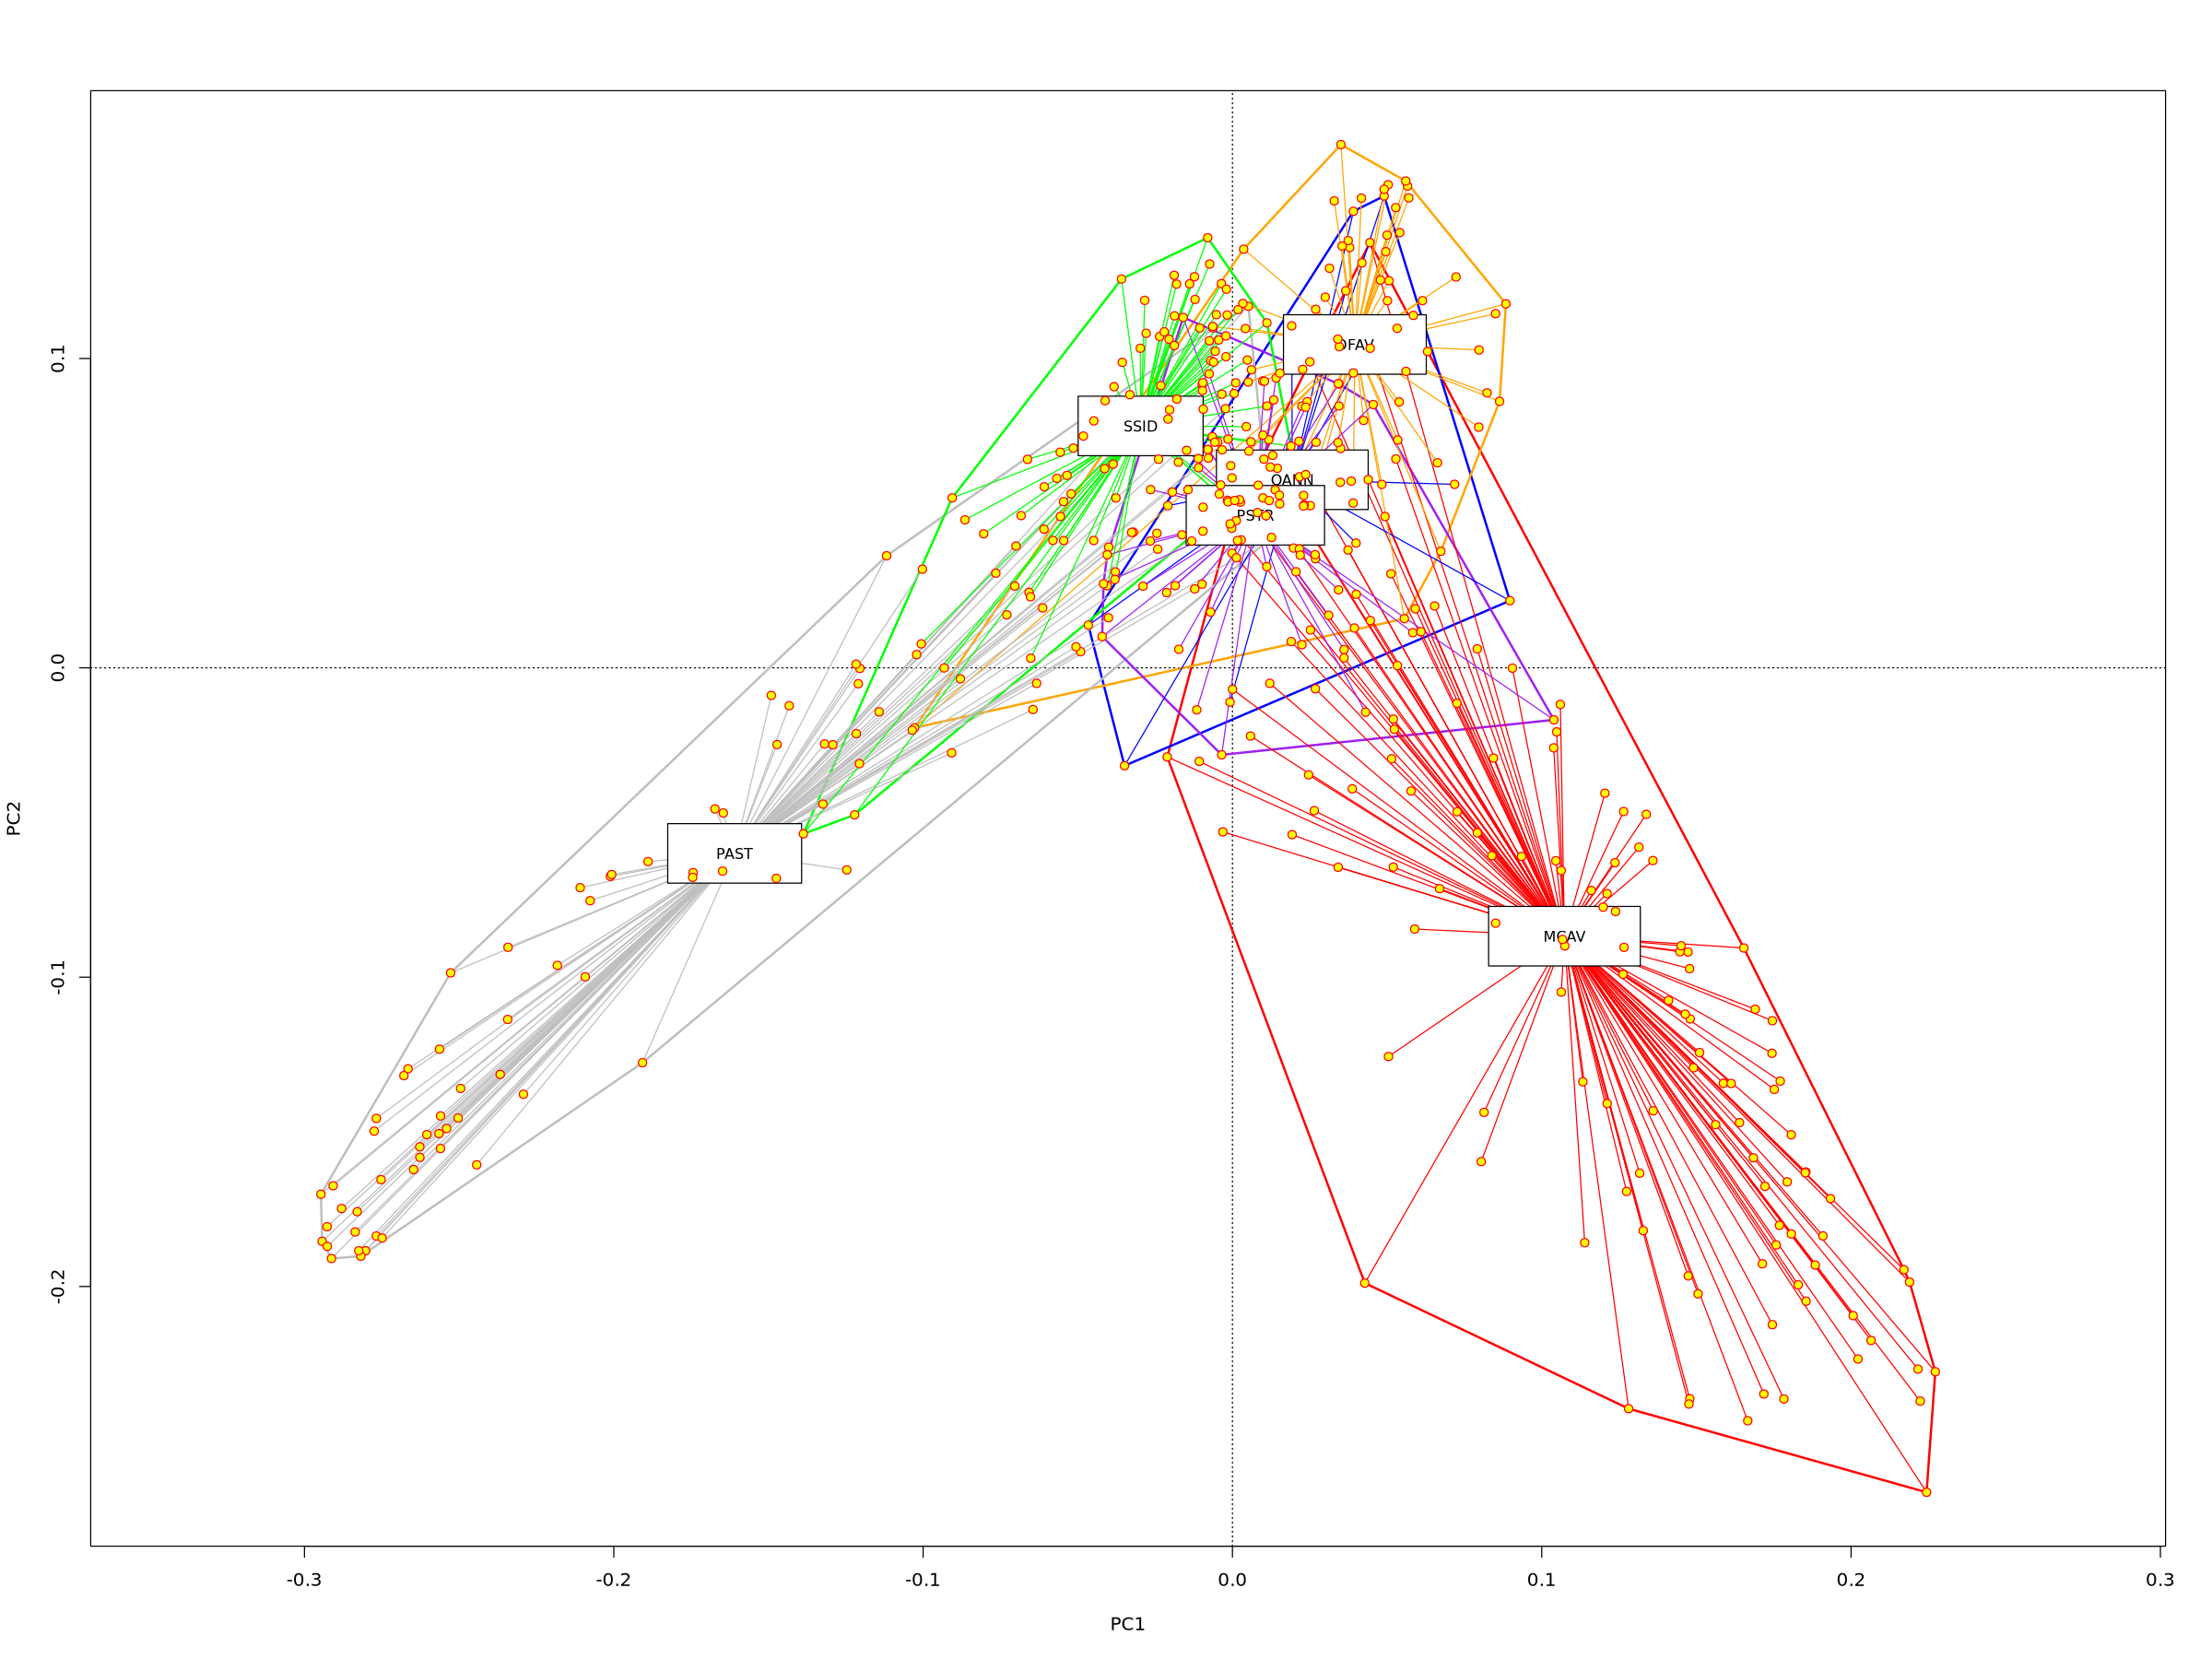

In [34]:
#by species 
disp <- "sites" 
scl <- "symmetric" 

#transforming species col from chr to factor 
otu_merged$Species <- factor(otu_merged$Species)
# PCA via rda()
pca_mod <- rda(ord)
#color points
# Color vector
col_vec <-c("red", "blue", "orange", "grey", "purple", "green")
cols <- col_vec[otu_merged$species]
plot(pca_mod, type = "n", scaling = scl, display = disp) 
ordihull(pca_mod, groups = otu_merged$Species, col = col_vec, scaling = scl, lwd = 2) 
ordispider(pca_mod, groups = otu_merged$Species, col = col_vec, scaling = scl, label = TRUE) 
points(pca_mod, display = disp, scaling = scl, pch = 21, col = "red", bg = "yellow")

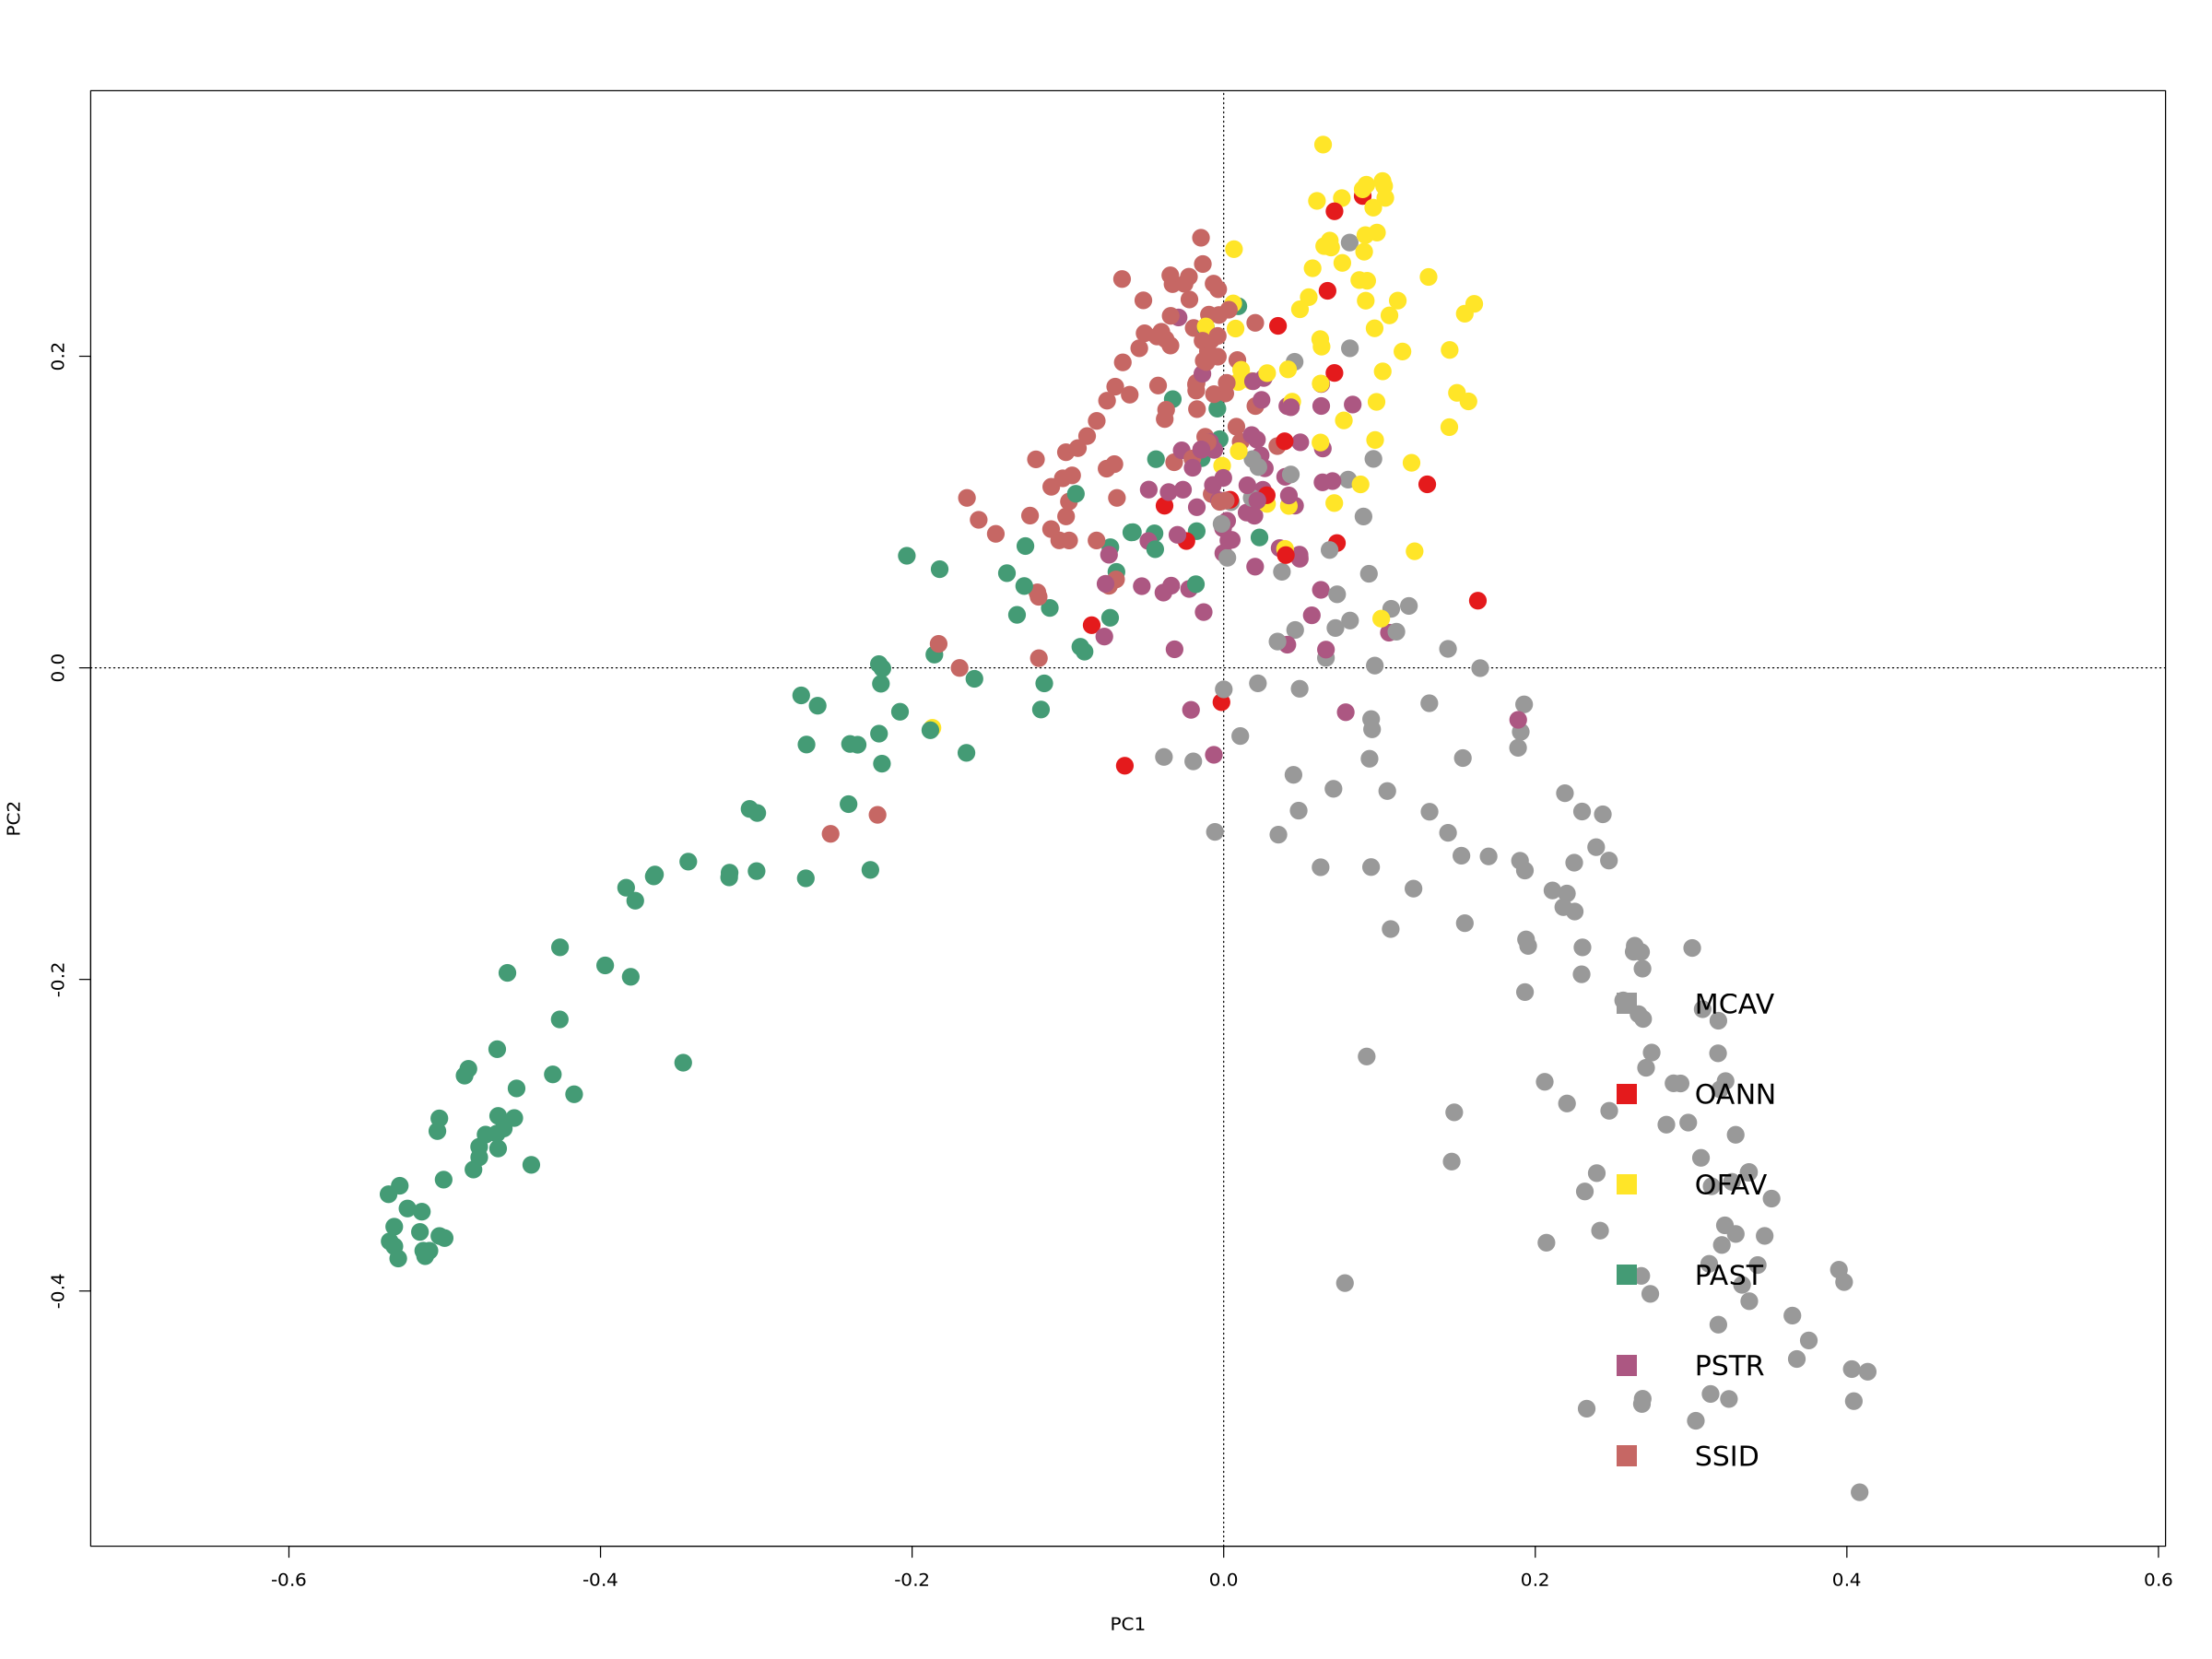

In [35]:
#transforming MonthYear col from chr to factor 
otu_merged$Species <- factor(otu_merged$Species)
# PCA via rda()
pca_spec <- rda(ord)
#color points
# Color vector
col_spec <-colorRampPalette(brewer.pal(9, "Set1"))(6)
# Generate a random set of colors 
    col_spec <- sample(col_spec, 6)
cols <- col_spec[otu_merged$Species]

#plot
plot(pca_spec, type = "n", scaling = 2, display = "sites")

points(pca_spec, display = "sites", scaling = 2,
       pch = 19, col = cols, cex = 2)

legend("bottomright",
       legend = levels(otu_merged$Species),
       bty = "n",
       col = col_spec,
       pch = 15,
       cex = 1.5, pt.cex=2.5)

### make and save PC species plot

## dendogram cluster analysis

### different dendogram clustering methods 

#### Maximum or complete linkage clustering: 
- It computes all pairwise dissimilarities between the elements in cluster 1 and the elements in cluster 2, and considers the largest value (i.e., maximum value) of these dissimilarities as the distance between the two clusters. It tends to produce more compact clusters.
#### Minimum or single linkage clustering: 
- It computes all pairwise dissimilarities between the elements in cluster 1 and the elements in cluster 2, and considers the smallest of these dissimilarities as a linkage criterion. It tends to produce long, “loose” clusters.
#### Mean or average linkage clustering: 
- It computes all pairwise dissimilarities between the elements in cluster 1 and the elements in cluster 2, and considers the average of these dissimilarities as the distance between the two clusters.
#### Centroid linkage clustering: 
- It computes the dissimilarity between the centroid for cluster 1 (a mean vector of length p variables) and the centroid for cluster 2.
#### Ward’s minimum variance method: 
- It minimizes the total within-cluster variance. At each step the pair of clusters with minimum between-cluster distance are merged.

In [37]:
dij <- vegdist(otu_nomit) ## bray curtis dissimilarity
clu <- hclust(dij, method = "average") 
# 2 clusters bc I know Date_16S is already driving into 2 clusters
grp <- cutree(clu, 6)

In [38]:
# plot settings
options(repr.plot.width=50, repr.plot.height=18)

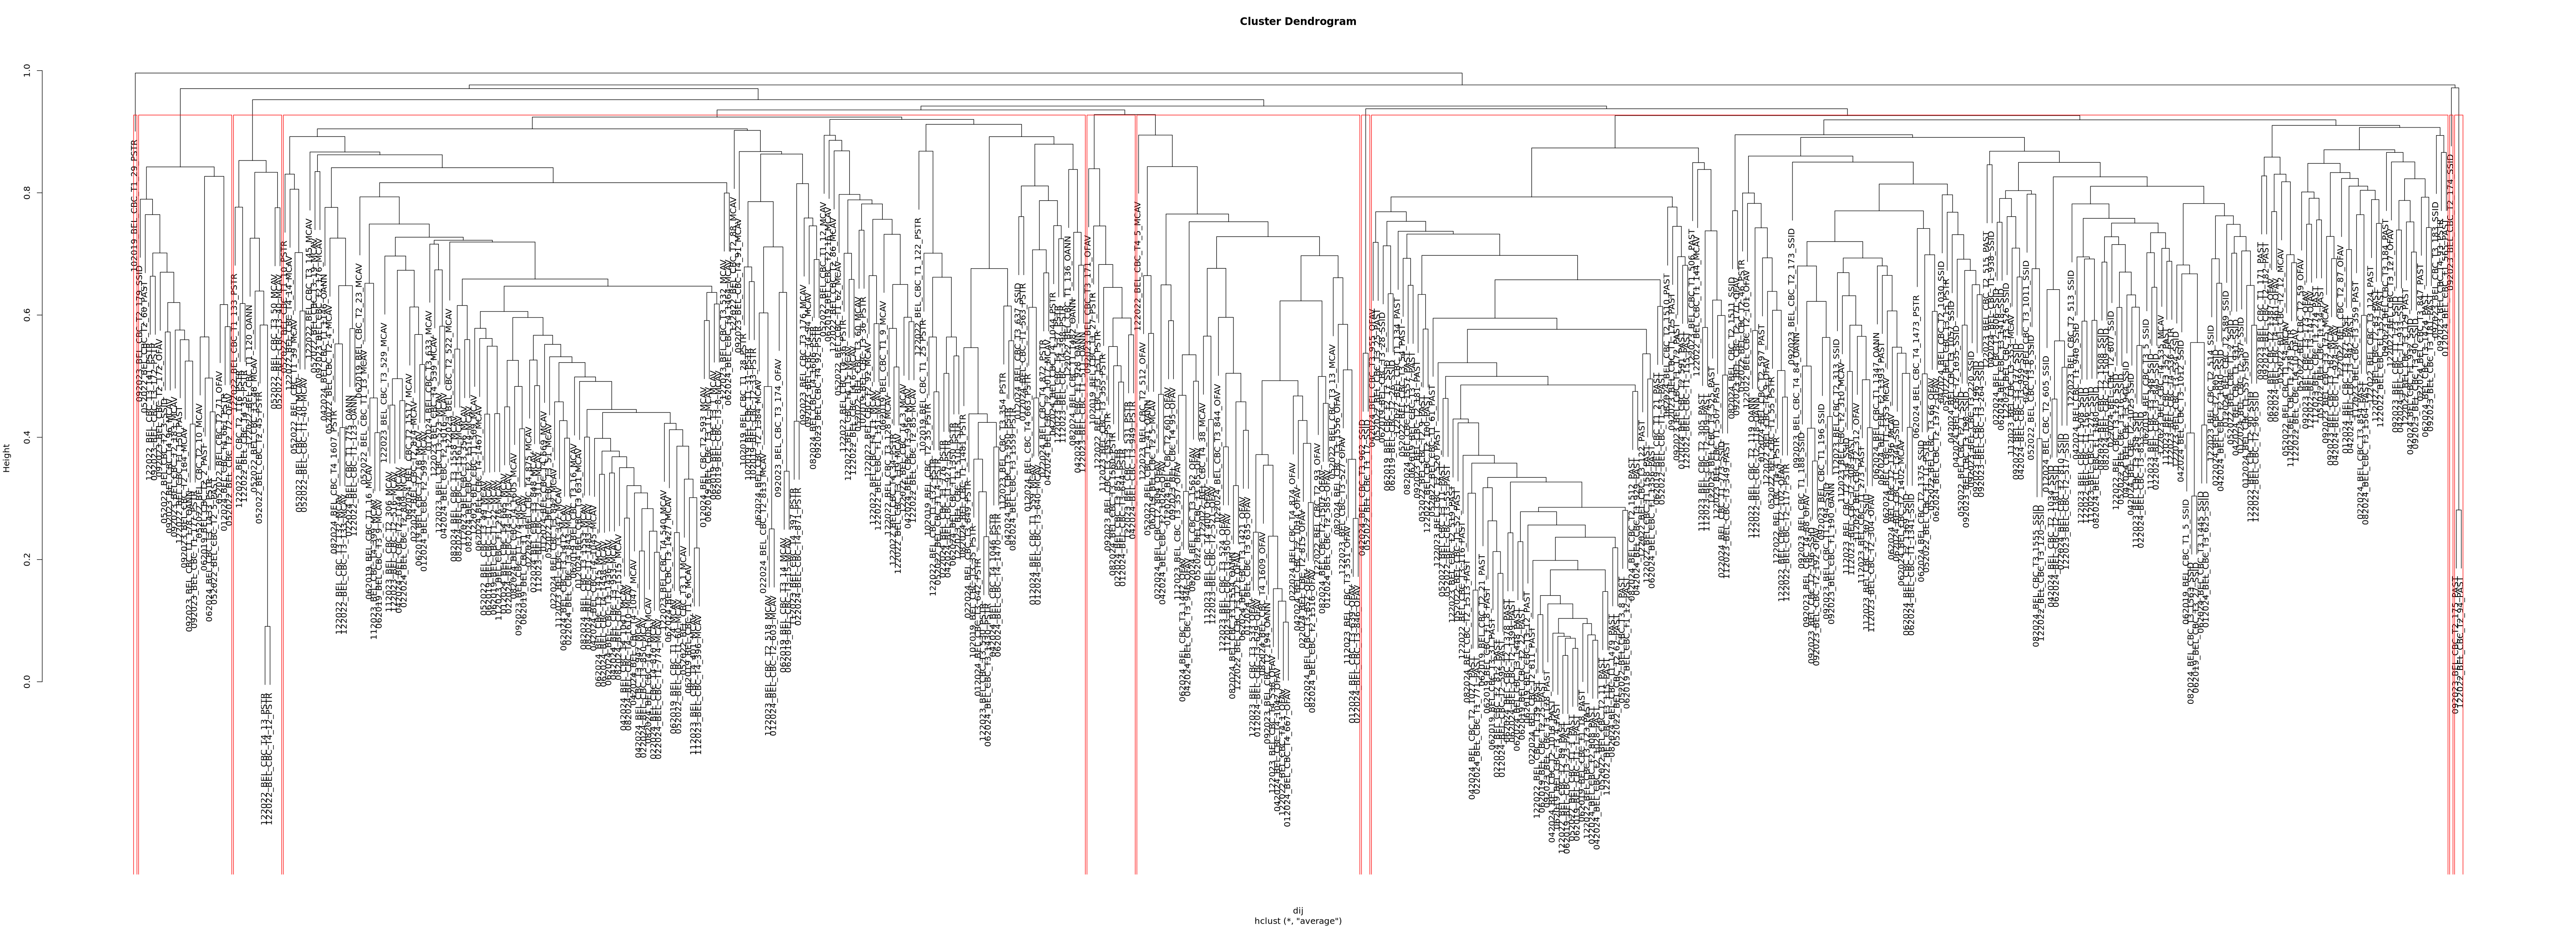

In [39]:
plot(clu)
rect.hclust(clu, k = 10, border = "red")

## heatmap with dendogram

# phyloseq NMDS

In [ ]:
#making this plot wider
options(repr.plot.width=30, repr.plot.height=15)
mycolors= colorRampPalette(brewer.pal(9, "Set1"))(20)
# Generate a random set of colors 
    mycolors <- sample(mycolors, 20)

In [ ]:
ps_norm_nmds <- ordinate(ps_norm_nomit, "NMDS", "bray", trymax=1000)

ps_nmds <- plot_ordination(ps_norm_nomit, ps_norm_nmds, type="samples", color="Health_status" )+ 
geom_point(size=12) + 
  labs(title = "NMDS Ordination of all samples with more than 10K reads",
       x = "NMDS1",
       y = "NMDS2") +
  scale_fill_manual(values = mycolors, drop = TRUE) +
  scale_color_manual(values = mycolors, drop = TRUE) +
  theme_bw() +
theme(
    legend.position = "right",
    legend.title = element_text(size = 25),
  legend.text = element_text(size = 20),
  legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.5, "cm"),   # make them taller
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 25)) +

guides(color = guide_legend(override.aes = list(size = 12))) 

ps_norm_nmds